# 06 · Embeddings, Similarity Search and Retrieval-Augmented Generation (RAG)

**Contents**

1. Embeddings: meaning as geometry
2. Similarity: dot product, cosine, Euclidean (and how they relate)
3. Sparse embeddings: bag-of-words and TF-IDF
4. Dense embeddings by matrix factorisation: LSA / truncated SVD
5. Learned neural embeddings: word2vec and contrastive sentence encoders
6. Retrieval: exact and approximate nearest neighbours
7. Evaluating retrieval: recall@k and MRR
8. Retrieval-augmented generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 1. Embeddings: meaning as geometry

An **embedding** is a map from an object (a word, a sentence, an image, a customer…) to a vector, $\mathrm{embed}:\text{object}\to\mathbb{R}^d$, built so that **similar objects get nearby vectors**. Once objects are vectors, "find related documents", "cluster claims", "recommend items" all become geometry: nearest neighbours, clustering, linear classifiers on top.

We have already met learned embeddings: the `nn.Embedding` layer (notebook 04), and every hidden layer of a trained network, whose activations $\mathbf{A}^{[L-1]}$ are the features the output layer works on (notebook 00).

The **distributional hypothesis** ("you shall know a word by the company it keeps") is the basis of most text embeddings: words and texts that appear in similar contexts should be close.

## 2. Similarity measures

For $\mathbf{a},\mathbf{b}\in\mathbb{R}^d$:

| Measure | Formula | Notes |
|---|---|---|
| dot product | $\mathbf{a}^\top\mathbf{b}$ | grows with the vectors' lengths |
| cosine similarity | $\cos(\mathbf{a},\mathbf{b}) = \dfrac{\mathbf{a}^\top\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}\in[-1,1]$ | only the **direction** matters |
| Euclidean distance | $\lVert\mathbf{a}-\mathbf{b}\rVert$ | sensitive to length |

**Why cosine for text.** A document and the same document repeated twice have count vectors $\mathbf{a}$ and $2\mathbf{a}$: cosine 1, but Euclidean distance $\lVert\mathbf{a}\rVert$. Length reflects how much text there is, not what it is about.

**For unit vectors the three agree.** If $\lVert\mathbf{a}\rVert = \lVert\mathbf{b}\rVert = 1$:
$$
\lVert\mathbf{a}-\mathbf{b}\rVert^2 = \lVert\mathbf{a}\rVert^2 + \lVert\mathbf{b}\rVert^2 - 2\mathbf{a}^\top\mathbf{b} = 2 - 2\cos(\mathbf{a},\mathbf{b}).
$$
So after L2-normalising all vectors, ranking by largest dot product = largest cosine = smallest Euclidean distance. That is why vector databases usually store normalised vectors and use the (fast) dot product.

## 3. Sparse embeddings: bag-of-words and TF-IDF

**Bag of words**: one dimension per vocabulary term, with value = count of the term in the document. Word order is lost, and the vectors have $|V|$ dimensions, mostly zeros.

**TF-IDF** reweights the counts so that terms that are frequent in *this* document but rare in the *collection* count most:
$$
\mathrm{tf}(t,d) = \text{count of } t \text{ in } d, \qquad
\mathrm{idf}(t) = \log\frac{N}{\mathrm{df}(t)}, \qquad
\mathrm{tfidf}(t,d) = \mathrm{tf}(t,d)\cdot\mathrm{idf}(t),
$$
with $N$ documents, and $\mathrm{df}(t)$ the number of documents containing $t$. A word in every document ("the") has $\mathrm{idf} = \log 1 = 0$ and vanishes; a word in 1 of 1,000 documents has weight $\log 1000\approx 6.9$. scikit-learn uses the smoothed $\mathrm{idf}(t) = \log\frac{1+N}{1+\mathrm{df}(t)} + 1$ and L2-normalises each row.

**Limitation: no notion of meaning.** Different words are orthogonal dimensions. "car" and "automobile" have cosine 0, and a query that shares no word with a relevant document scores 0 (the *vocabulary mismatch* problem).

We use a small corpus of 24 short documents on four topics.

In [2]:
docs = [
    # 0-5: cars
    "The car needs a new engine and the brakes are worn.",
    "An automobile with a diesel engine uses less fuel on the motorway.",
    "Check the tyre pressure before a long drive on the motorway.",
    "The mechanic repaired the engine and replaced the brakes of the vehicle.",
    "Electric vehicles need charging stations along the road.",
    "The automobile was towed after the crash on the road.",
    # 6-11: cooking
    "Bake the bread in a hot oven for forty minutes.",
    "Add salt and pepper to the soup and let it simmer.",
    "The recipe uses flour, butter and sugar to make a cake.",
    "Fry the onions in olive oil before adding the tomatoes.",
    "A good soup needs fresh vegetables and a slow simmer.",
    "Knead the dough and let the bread rise before baking in the oven.",
    # 12-17: finance
    "The bank raised interest rates to control inflation.",
    "Investors bought shares when the stock market fell.",
    "A mortgage is a loan from the bank to buy a house.",
    "Inflation reduces the value of savings in the bank.",
    "The company paid a dividend to its shareholders.",
    "Interest on the loan is paid every month to the bank.",
    # 18-23: machine learning
    "The neural network was trained with gradient descent.",
    "A decision tree splits the data on the most informative feature.",
    "Regularisation reduces overfitting of the model on training data.",
    "The model learns embeddings of words from large text corpora.",
    "Cross-validation estimates how the model performs on new data.",
    "Gradient boosting trains trees sequentially on the residuals.",
]
topic = np.repeat(["cars", "cooking", "finance", "ML"], 6)

from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(stop_words="english")
Xtfidf = vec.fit_transform(docs)                      # sparse (24 x |V|), rows L2-normalised
print("TF-IDF matrix:", Xtfidf.shape, f"({Xtfidf.nnz / np.prod(Xtfidf.shape):.1%} non-zero)")
vocab = vec.vocabulary_
car, auto = Xtfidf[:, vocab["car"]].toarray().ravel(), Xtfidf[:, vocab["automobile"]].toarray().ravel()
print("TF-IDF term vectors: cos('car', 'automobile') =", round(float(car @ auto / (np.linalg.norm(car) * np.linalg.norm(auto))), 3))

TF-IDF matrix: (24, 112) (5.1% non-zero)
TF-IDF term vectors: cos('car', 'automobile') = 0.0


## 4. Dense embeddings by matrix factorisation: LSA

**Latent semantic analysis** factorises the document–term matrix $\mathbf{X}\in\mathbb{R}^{N\times|V|}$ with a truncated SVD:
$$
\mathbf{X}\approx\mathbf{U}_k\boldsymbol{\Sigma}_k\mathbf{V}_k^\top, \qquad \text{document embeddings} = \mathbf{U}_k\boldsymbol{\Sigma}_k\in\mathbb{R}^{N\times k},\quad \text{term embeddings} = \mathbf{V}_k\boldsymbol{\Sigma}_k\in\mathbb{R}^{|V|\times k}.
$$

- **Eckart–Young theorem**: keeping the top $k$ singular values gives the best rank-$k$ approximation of $\mathbf{X}$ in squared (Frobenius) error. LSA is "PCA without centring" for text.
- Terms that occur in **similar contexts** (with the same other words) load on the same latent dimensions, even if they never occur together. So "car" and "automobile" (both with "engine", "road", "motorway") become similar.
- A new query $\mathbf{q}$ (a TF-IDF row) is embedded by projecting it: $\mathbf{q}\mathbf{V}_k$.

In [3]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

svd = TruncatedSVD(n_components=4, random_state=0).fit(Xtfidf)
doc_lsa = normalize(svd.transform(Xtfidf))                         # (24 x 4), unit rows
term_lsa = normalize(svd.components_.T * svd.singular_values_)     # (|V| x 4), unit rows
cos_terms = lambda a, b: float(term_lsa[vocab[a]] @ term_lsa[vocab[b]])
for a, b in [("car", "automobile"), ("car", "vehicle"), ("bread", "oven"), ("car", "bread"), ("bank", "loan")]:
    print(f"LSA cos({a!r:>12}, {b!r:<12}) = {cos_terms(a, b):+.2f}")

LSA cos(       'car', 'automobile') = +0.80
LSA cos(       'car', 'vehicle'   ) = +0.96
LSA cos(     'bread', 'oven'      ) = +1.00
LSA cos(       'car', 'bread'     ) = +0.04
LSA cos(      'bank', 'loan'      ) = +0.98


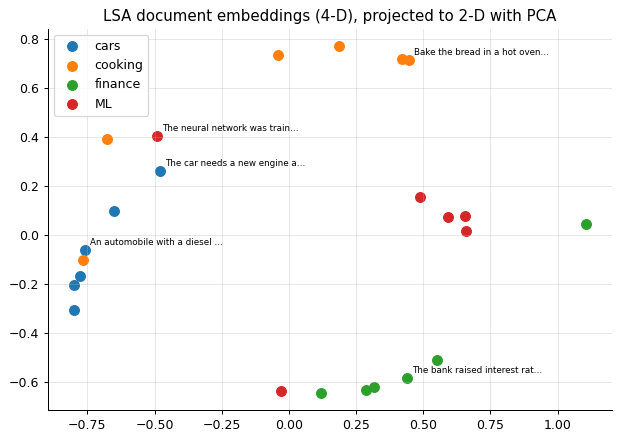

In [4]:
from sklearn.decomposition import PCA
P2 = PCA(2).fit_transform(doc_lsa)
fig, ax = plt.subplots(figsize=(7, 5))
for t, c in zip(["cars", "cooking", "finance", "ML"], ["C0", "C1", "C2", "C3"]):
    ax.scatter(*P2[topic == t].T, s=60, color=c, label=t)
for i in [0, 1, 6, 12, 18]:
    ax.annotate(docs[i][:28] + "…", P2[i], fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.legend(); ax.set_title("LSA document embeddings (4-D), projected to 2-D with PCA")
plt.tight_layout(); plt.show()

## 5. Learned neural embeddings

**word2vec (skip-gram)** learns a vector $\mathbf{u}_w$ for each word so that it predicts the words around it. For a centre word $c$ and a context word $o$ it models
$$
P(o\mid c) = \frac{\exp(\mathbf{u}_o'^\top\mathbf{u}_c)}{\sum_{w\in V}\exp(\mathbf{u}_w'^\top\mathbf{u}_c)},
$$
a softmax classifier (ML notes 04) whose input is the centre word's embedding, trained with cross-entropy on (centre, context) pairs from a large corpus. The sum over $V$ is expensive, so it is approximated with **negative sampling** (a few binary logistic regressions against random words). Words with similar contexts end up with similar vectors, and famously some relations become directions: $\mathbf{u}_{\text{king}} - \mathbf{u}_{\text{man}} + \mathbf{u}_{\text{woman}}\approx\mathbf{u}_{\text{queen}}$. Up to details, word2vec is implicitly factorising a word–context co-occurrence matrix (Levy & Goldberg, 2014), so it is a close relative of LSA.

**Sentence / document encoders** (Sentence-BERT, E5, OpenAI and other embedding APIs) run a transformer **encoder** (notebook 05) over the text and pool the token outputs (e.g. their mean) into one vector. They are trained **contrastively**: for a query $q$ with a relevant passage $p^+$ and other passages $p_1^-,\dots$ in the batch, minimise
$$
J = -\log\frac{\exp\big(\cos(q, p^+)/\tau\big)}{\exp\big(\cos(q, p^+)/\tau\big) + \sum_j\exp\big(\cos(q, p_j^-)/\tau\big)} .
$$
This **InfoNCE** loss is just softmax cross-entropy where the "classes" are the candidate passages and the correct class is the relevant one. It pulls matching pairs together and pushes non-matching ones apart. Because they are trained on meaning rather than on shared words, these models solve the vocabulary-mismatch problem: "my car broke down" is close to "automobile repair".

```python
# pip install sentence-transformers   (downloads a ~90 MB model; not run here)
from sentence_transformers import SentenceTransformer
encoder = SentenceTransformer("all-MiniLM-L6-v2")
E = encoder.encode(docs, normalize_embeddings=True)          # (N, 384) unit vectors
q = encoder.encode(["my car broke down"], normalize_embeddings=True)[0]
top5 = np.argsort(-(E @ q))[:5]                               # cosine = dot product for unit vectors
```

## 6. Retrieval: nearest neighbours

Given a query embedding $\mathbf{q}$ and document embeddings $\mathbf{E}\in\mathbb{R}^{N\times d}$ (unit rows), **retrieval** = return the $k$ documents with the largest $\mathbf{E}\mathbf{q}$.

- **Exact search** costs $O(Nd)$ per query: fine up to ~$10^5$–$10^6$ vectors, one matrix–vector product.
- **Approximate nearest neighbours (ANN)** for larger collections trade a little recall for large speed-ups: graph-based (**HNSW**: greedy walk on a navigable proximity graph, roughly $O(\log N)$ hops), clustering-based (**IVF**: only search the few clusters closest to the query), and compression (**product quantisation**). Libraries and databases: FAISS, hnswlib, pgvector, Qdrant, Chroma, …
- **Hybrid search** combines a sparse score (TF-IDF/BM25: exact keywords, IDs, rare names) with a dense score (meaning), often followed by a **re-ranker**, a cross-encoder that reads query and passage together and is more accurate but too slow to run on the whole collection.

In [5]:
queries = {  # query -> relevant topic (ground truth: the 6 documents of that topic)
    "my automobile has engine trouble": "cars",
    "vehicle crash on the motorway": "cars",
    "how to bake a cake in the oven": "cooking",
    "vegetable soup recipe": "cooking",
    "loan interest from the bank": "finance",
    "stock market investors and shares": "finance",
    "training a model with gradient descent": "ML",
    "decision trees and boosting": "ML",
    # short queries whose words occur in only ONE document of the topic
    "fix my car": "cars", "tyre pressure": "cars", "charging stations": "cars",
    "olive oil": "cooking", "dough": "cooking",
    "mortgage for a house": "finance", "dividend": "finance",
    "overfitting": "ML", "residuals": "ML",
}

tiebreak = np.random.default_rng(0).permutation(len(docs))   # so ties don't favour low document indices

def retrieve(q, method, k=5):
    qv = vec.transform([q])
    if method == "tfidf":
        scores = (Xtfidf @ qv.T).toarray().ravel()
    else:
        scores = doc_lsa @ normalize(svd.transform(qv)).ravel()
    order = np.lexsort((tiebreak, -scores))        # sort by score; ties broken in a fixed random order
    return order[:k], scores[order[:k]]

for q in ["tyre pressure", "my automobile has engine trouble"]:
    for method in ["tfidf", "lsa"]:
        idx, sc = retrieve(q, method, k=3)
        print(f"[{method:>5}] {q!r}")
        for i, s in zip(idx, sc): print(f"         {s:+.2f}  ({topic[i]:>7}) {docs[i]}")

[tfidf] 'tyre pressure'
         +0.59  (   cars) Check the tyre pressure before a long drive on the motorway.
         +0.00  (finance) The bank raised interest rates to control inflation.
         +0.00  (     ML) Cross-validation estimates how the model performs on new data.
[  lsa] 'tyre pressure'
         +1.00  (   cars) Check the tyre pressure before a long drive on the motorway.
         +0.98  (   cars) The automobile was towed after the crash on the road.
         +0.98  (   cars) An automobile with a diesel engine uses less fuel on the motorway.
[tfidf] 'my automobile has engine trouble'
         +0.53  (   cars) An automobile with a diesel engine uses less fuel on the motorway.
         +0.35  (   cars) The automobile was towed after the crash on the road.
         +0.24  (   cars) The car needs a new engine and the brakes are worn.
[  lsa] 'my automobile has engine trouble'
         +1.00  (   cars) An automobile with a diesel engine uses less fuel on the motorway.
       

## 7. Evaluating retrieval

Retrieval is evaluated like a ranking problem, on queries whose relevant documents are known:

- **Precision@k**: fraction of the top $k$ results that are relevant.
- **Recall@k**: fraction of all relevant documents that appear in the top $k$. It is what matters for RAG: if the right passage isn't retrieved, the generator can't use it. (Here every query has 6 relevant documents, so we use recall@6.)
- **MRR** (mean reciprocal rank): the average over queries of $1/\text{rank of the first relevant result}$.

In [6]:
def evaluate(method):
    p3, r6, rr = [], [], []
    for q, t in queries.items():
        ranking, _ = retrieve(q, method, k=len(docs))
        rel = topic[ranking] == t
        p3.append(rel[:3].mean()); r6.append(rel[:6].sum() / (topic == t).sum()); rr.append(1 / (np.argmax(rel) + 1))
    return np.mean(p3), np.mean(r6), np.mean(rr)

for method in ["tfidf", "lsa"]:
    p3, r6, mrr = evaluate(method)
    print(f"{method:>5}: precision@3 = {p3:.2f}   recall@6 = {r6:.2f}   MRR = {mrr:.2f}")

tfidf: precision@3 = 0.69   recall@6 = 0.47   MRR = 1.00
  lsa: precision@3 = 0.84   recall@6 = 0.70   MRR = 1.00


Both methods put a relevant document first for every query (MRR = 1): the exact word match finds it. The difference is in the rest of the ranking. For a query like "tyre pressure", only one document contains those words. TF-IDF gives every other document a score of exactly **0**, so ranks 2–6 are an arbitrary tie. LSA still scores the other car documents highly, because "tyre" and "motorway", "drive", "engine" load on the same latent dimension. Hence the higher precision@3 and recall@6.

LSA is also visibly noisy. With 4 dimensions learned from 24 documents, a cooking recipe scores 0.99 for "my automobile has engine trouble". The number of dimensions $k$ is a hyperparameter (tune it on validation queries), and LSA is only a demonstration of the principle. Real systems use neural encoders trained on millions of query–passage pairs, often combined with a keyword score (hybrid search), because exact matches on rare terms are what TF-IDF/BM25 does best.

## 8. Retrieval-augmented generation (RAG)

An LLM only knows what was in its training data (up to a cut-off date, never your internal documents), and it can produce fluent but wrong answers (*hallucinations*). **RAG** retrieves relevant passages at question time and gives them to the LLM as context:

```
offline (indexing):   documents → split into chunks → embed each chunk → store vectors (+ text, metadata) in an index
online  (answering):  question  → embed → retrieve top-k chunks (→ re-rank) → prompt = instructions + chunks + question → LLM → answer (+ citations)
```

**Design choices that matter most**
- **Chunking**: passages of a few hundred tokens, often with some overlap, split on natural boundaries (sections, paragraphs). Too large dilutes the embedding; too small loses context.
- **Embedding model**: must suit the language and domain; queries and documents must be embedded with the same model.
- **k and re-ranking**: retrieve generously (high recall), then re-rank and keep the few best, to stay within the context window.
- **Prompting**: instruct the model to answer only from the provided context, to say when the answer isn't there, and to cite chunk IDs.
- **Metadata filters and access control**: only retrieve documents the user is allowed to see. This matters in practice with confidential client data.

**Why it works and where it fails.** It gives up-to-date, domain-specific, citable answers without retraining the LLM. Most failures are **retrieval failures** (the right chunk wasn't in the top $k$), so measure recall@k on real questions before tuning the prompt. The generator can still misread or ignore the context, so evaluate faithfulness too.

## Summary

- An embedding maps objects to vectors so that similar objects are close; after L2-normalisation, dot product, cosine and Euclidean distance give the same ranking ($\lVert\mathbf{a}-\mathbf{b}\rVert^2 = 2-2\cos$).
- TF-IDF: sparse, exact-word matching, weights rare terms higher; it can't match synonyms.
- LSA (truncated SVD) gives dense embeddings where co-occurring terms share dimensions; word2vec and contrastive sentence encoders (InfoNCE = softmax cross-entropy over candidates) learn much better ones.
- Retrieval = nearest neighbours (exact, or ANN such as HNSW/IVF for scale), often hybrid sparse+dense with a re-ranker; evaluate with recall@k and MRR.
- RAG = retrieve relevant chunks, then generate from them. Chunking, retrieval recall and access control matter more than prompt wording.